In [24]:
# Importing Libraries
import pandas as pd                              # Pandas: work with and analyze tabular data
from datasets import load_dataset               # Hugging Face: load the job postings dataset
import matplotlib.pyplot as plt                 # Matplotlib: create charts and visualizations


# Loading Data
dataset = load_dataset('lukebarousse/data_jobs') # Download/load Luke's job dataset
df = dataset['train'].to_pandas()                # Convert the dataset into a Pandas DataFrame


# Data Cleanup
df['job_posted_date'] = pd.to_datetime(
    df['job_posted_date']
) 

In [25]:
# Load the software-job CSV into a new DataFrame
df_US_software_pivot = pd.read_csv(
    "https://lukeb.co/software_csv",
    index_col="job_posted_month"
)

# Display the imported DataFrame
df_US_software_pivot

,Front-End Developer,Back-End Developer,Full-Stack Developer,UI/UX Designer
job_posted_month,,,,
January,13619,9827,5108,4348
February,11456,9116,7298,4284
March,11102,8178,5814,4159
April,14037,9209,7232,4220
May,12126,8864,6718,4980
June,12003,8065,5902,4781
July,11914,8061,6839,4344
August,11571,8191,7413,4104
September,14016,8447,6139,4094


In [26]:
# Create a small January job-postings DataFrame
job_postings_jan = pd.DataFrame({
    'job_id': [1, 2, 3, 4, 5],
    'job_title': [
        'Data Scientist',
        'Data Analyst',
        'Machine Learning Engineer',
        'Data Scientist',
        'Data Engineer'
    ],
    'company': [
        'Company A',
        'Company B',
        'Company C',
        'Company D',
        'Company E'
    ],
    'job_posted_date': [
        '2024-01-02',
        '2024-01-07',
        '2024-01-14',
        '2024-01-19',
        '2024-01-24'
    ]
})

# Convert the date column from text into datetime values
job_postings_jan['job_posted_date'] = pd.to_datetime(
    job_postings_jan['job_posted_date']
)

job_postings_jan

,job_id,job_title,company,job_posted_date
0,1,Data Scientist,Company A,2024-01-02
1,2,Data Analyst,Company B,2024-01-07
2,3,Machine Learning Engineer,Company C,2024-01-14
3,4,Data Scientist,Company D,2024-01-19
4,5,Data Engineer,Company E,2024-01-24


In [27]:
# Create a small February job-postings DataFrame
job_postings_feb = pd.DataFrame({
    'job_id': [6, 7, 8, 9, 10],
    'job_title': [
        'Data Scientist',
        'Data Analyst',
        'Machine Learning Engineer',
        'Data Scientist',
        'Data Engineer'
    ],
    'company': [
        'Company F',
        'Company G',
        'Company H',
        'Company I',
        'Company J'
    ],
    'job_posted_date': [
        '2024-02-05',
        '2024-02-09',
        '2024-02-12',
        '2024-02-18',
        '2024-02-22'
    ]
})

# Convert the date column from text into datetime values
job_postings_feb['job_posted_date'] = pd.to_datetime(
    job_postings_feb['job_posted_date']
)

job_postings_feb

,job_id,job_title,company,job_posted_date
0,6,Data Scientist,Company F,2024-02-05
1,7,Data Analyst,Company G,2024-02-09
2,8,Machine Learning Engineer,Company H,2024-02-12
3,9,Data Scientist,Company I,2024-02-18
4,10,Data Engineer,Company J,2024-02-22


In [28]:
job_postings_jan

,job_id,job_title,company,job_posted_date
0,1,Data Scientist,Company A,2024-01-02
1,2,Data Analyst,Company B,2024-01-07
2,3,Machine Learning Engineer,Company C,2024-01-14
3,4,Data Scientist,Company D,2024-01-19
4,5,Data Engineer,Company E,2024-01-24


In [29]:
job_postings_feb

,job_id,job_title,company,job_posted_date
0,6,Data Scientist,Company F,2024-02-05
1,7,Data Analyst,Company G,2024-02-09
2,8,Machine Learning Engineer,Company H,2024-02-12
3,9,Data Scientist,Company I,2024-02-18
4,10,Data Engineer,Company J,2024-02-22


In [30]:
pd.concat([job_postings_jan, job_postings_feb], ignore_index=True)

,job_id,job_title,company,job_posted_date
0,1,Data Scientist,Company A,2024-01-02
1,2,Data Analyst,Company B,2024-01-07
2,3,Machine Learning Engineer,Company C,2024-01-14
3,4,Data Scientist,Company D,2024-01-19
4,5,Data Engineer,Company E,2024-01-24
5,6,Data Scientist,Company F,2024-02-05
6,7,Data Analyst,Company G,2024-02-09
7,8,Machine Learning Engineer,Company H,2024-02-12
8,9,Data Scientist,Company I,2024-02-18
9,10,Data Engineer,Company J,2024-02-22


In [31]:
df['job_posted_month'] = df['job_posted_date'].dt.strftime('%b')



In [32]:
# Get all unique month names from the DataFrame
months = df['job_posted_month'].unique()

# Build a dictionary where:
#   - The KEY is the month name (e.g. "Jan")
#   - The VALUE is a DataFrame containing only rows for that month
dict_months = {
    month: df[df['job_posted_month'] == month]   # ":" separates key from value in a dictionary
    for month in months                          # Loop through every month in the 'months' array
}

# Display the finished dictionary
dict_months

{'Jun':                   job_title_short  \
 0            Senior Data Engineer   
 8                Business Analyst   
 16                  Data Engineer   
 17                 Data Scientist   
 24                 Data Scientist   
 ...                           ...   
 785347             Data Scientist   
 785571               Data Analyst   
 785617               Data Analyst   
 785669  Machine Learning Engineer   
 785675               Data Analyst   
 
                                                 job_title  \
 0       Senior Clinical Data Engineer / Principal Clin...   
 8                Technology & Operations Business Analyst   
 16                                      Big Data Engineer   
 17                                 Data Science Team Lead   
 24                          Data Scientist (DataLab Team)   
 ...                                                   ...   
 785347                    Practicante Científico de Datos   
 785571  Credits Monitoring and Reporti

# Concatenating DataFrames for Quarter 1

The goal is to combine the January, February, and March job-posting DataFrames into one Quarter 1 DataFrame.

`pd.concat()` stacks DataFrames together.

In this example, the rows from February are placed under January, and the rows from March are placed under February.

This is different from `merge()`:

- `concat()` stacks tables together.
- `merge()` combines tables by matching a common key or column.

In [33]:
# Combine the January, February, and March DataFrames into one Q1 DataFrame
df_q1 = pd.concat(
    [
        dict_months['Jan'],   # Get the January DataFrame from the dictionary
        dict_months['Feb'],   # Get the February DataFrame from the dictionary
        dict_months['Mar']    # Get the March DataFrame from the dictionary
    ],
    ignore_index=True         # Create a new clean index: 0, 1, 2, 3...
)

# Display the combined Quarter 1 DataFrame
df_q1

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_posted_month
0,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,"['r', 'python', 'sql', 'nosql', 'power bi', 't...","{'analyst_tools': ['power bi', 'tableau'], 'pr...",Jan
1,Data Scientist,Data Scientist,"Zaventem, Belgium",via BeBee Belgique,Full-time,False,Belgium,2023-01-31 13:53:38,False,False,Belgium,NaN,NaN,NaN,Devoteam,"['r', 'python', 'sql', 'pandas', 'numpy', 'sci...","{'libraries': ['pandas', 'numpy', 'scikit-lear...",Jan
2,Data Engineer,Data Engineer,"Fort Worth, TX",via LinkedIn,Full-time,False,"Texas, United States",2023-01-25 13:24:01,False,False,United States,NaN,NaN,NaN,Programmers.io,"['sql', 'python']","{'programming': ['sql', 'python']}",Jan
3,Data Engineer,Data Engineer,"San Mateo, CA",via LinkedIn,Full-time,False,"California, United States",2023-01-28 13:07:30,False,True,United States,NaN,NaN,NaN,Verkada,"['sql', 'python', 'aws', 'looker']","{'analyst_tools': ['looker'], 'cloud': ['aws']...",Jan
4,Data Scientist,Data Scientist,"São Paulo, State of São Paulo, Brazil",via BeBee,Full-time,False,Brazil,2023-01-03 23:02:27,False,False,Brazil,NaN,NaN,NaN,Mars,"['python', 'sql', 'azure']","{'cloud': ['azure'], 'programming': ['python',...",Jan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
220479,Software Engineer,DevOps Engineer,Singapura,melalui Trabajo.org,Pekerjaan tetap,False,Singapore,2023-03-13 06:16:16,False,False,Singapore,NaN,NaN,NaN,CAREERSTAR INTERNATIONAL PTE. LTD.,"['bash', 'python', 'perl', 'linux', 'unix', 'k...","{'os': ['linux', 'unix'], 'other': ['kubernete...",Mar
220480,Data Analyst,CRM Data Analyst,"Bad Rodach, Jerman",melalui BeBee Deutschland,Pekerjaan tetap,False,Germany,2023-03-12 06:18:18,False,False,Germany,NaN,NaN,NaN,HABA FAMILYGROUP,"['sas', 'sas', 'sql', 'excel']","{'analyst_tools': ['sas', 'excel'], 'programmi...",Mar
220481,Business Analyst,Commercial Analyst - Start Now,Malaysia,melalui Ricebowl,Pekerjaan tetap,False,Malaysia,2023-03-12 06:32:36,False,False,Malaysia,NaN,NaN,NaN,Lendlease Corporation,"['powerpoint', 'excel']","{'analyst_tools': ['powerpoint', 'excel']}",Mar
220482,Data Engineer,"Principal Associate, Data Engineer (Remote-Eli...","Newark, New Jersey, Amerika Serikat",melalui Recruit.net,Pekerjaan tetap,False,Sudan,2023-03-12 06:32:15,False,False,Sudan,NaN,NaN,NaN,Capital One,"['python', 'go', 'nosql', 'sql', 'mongo', 'she...","{'cloud': ['aws', 'snowflake', 'azure', 'redsh...",Mar


In [34]:
dict_months['Jan']

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_posted_month
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,"['r', 'python', 'sql', 'nosql', 'power bi', 't...","{'analyst_tools': ['power bi', 'tableau'], 'pr...",Jan
20,Data Scientist,Data Scientist,"Zaventem, Belgium",via BeBee Belgique,Full-time,False,Belgium,2023-01-31 13:53:38,False,False,Belgium,NaN,NaN,NaN,Devoteam,"['r', 'python', 'sql', 'pandas', 'numpy', 'sci...","{'libraries': ['pandas', 'numpy', 'scikit-lear...",Jan
39,Data Engineer,Data Engineer,"Fort Worth, TX",via LinkedIn,Full-time,False,"Texas, United States",2023-01-25 13:24:01,False,False,United States,NaN,NaN,NaN,Programmers.io,"['sql', 'python']","{'programming': ['sql', 'python']}",Jan
53,Data Engineer,Data Engineer,"San Mateo, CA",via LinkedIn,Full-time,False,"California, United States",2023-01-28 13:07:30,False,True,United States,NaN,NaN,NaN,Verkada,"['sql', 'python', 'aws', 'looker']","{'analyst_tools': ['looker'], 'cloud': ['aws']...",Jan
55,Data Scientist,Data Scientist,"São Paulo, State of São Paulo, Brazil",via BeBee,Full-time,False,Brazil,2023-01-03 23:02:27,False,False,Brazil,NaN,NaN,NaN,Mars,"['python', 'sql', 'azure']","{'cloud': ['azure'], 'programming': ['python',...",Jan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785699,Software Engineer,Simulation Engineer,"Prague, Czechia",via Trabajo.org,Full-time,False,Czechia,2023-01-16 06:35:30,False,False,Czechia,NaN,NaN,NaN,Ricardo Prague s.r.o.,"['powerpoint', 'excel']","{'analyst_tools': ['powerpoint', 'excel']}",Jan
785700,Data Engineer,Data Engineer Ssr/Sr,"Mexico City, CDMX, Mexico",via Trabajo.org,Full-time,False,Mexico,2023-01-12 06:19:55,True,False,Mexico,NaN,NaN,NaN,Tsoft,"['python', 'r', 'azure', 'aws', 'gcp', 'spark'...","{'cloud': ['azure', 'aws', 'gcp'], 'libraries'...",Jan
785703,Data Analyst,Data Analyst - CRYPTOGRAPHY - Full-time,Anywhere,via Snagajob,Full-time,True,"Texas, United States",2023-01-28 06:02:55,True,False,United States,NaN,NaN,NaN,Axelon Services Corporation,NaN,NaN,Jan
785704,Business Analyst,Business Analyst,"Prague, Czechia",via Trabajo.org,Full-time,False,Czechia,2023-01-16 06:35:20,False,False,Czechia,NaN,NaN,NaN,Cleverlance,NaN,NaN,Jan


In [35]:
# Count how many job postings came from each month in the Q1 DataFrame
df_q1['job_posted_month'].value_counts()

job_posted_month
Jan    91822
Feb    64578
Mar    64084
Name: count, dtype: int64

<Axes: xlabel='job_posted_month'>

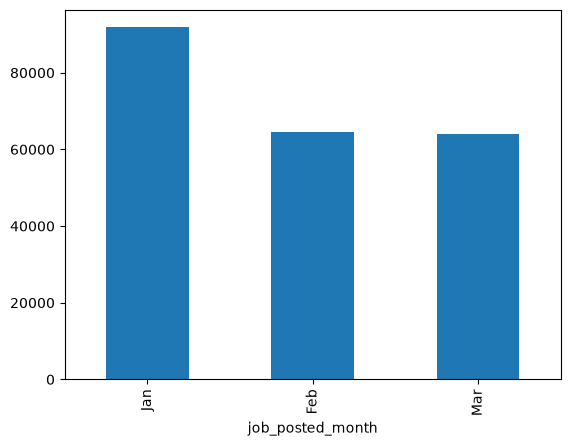

In [36]:
# Count the postings for each Q1 month and display them as a bar chart
df_q1['job_posted_month'].value_counts().plot(
    kind='bar'              # Use a bar chart
)